# Hybrid Recipe Search and Personalized Recommendation System
### DSCI 641 — Advanced Data Science Capstone | Drexel University MSDS
**Ian Auger** &nbsp;·&nbsp; June 2026

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, HTML

# Project palette (aligned with CS 615 presentation)
C_GREEN  = '#3d4a35'
C_CREAM  = '#f5f0e8'
C_GOLD   = '#8a7535'
C_RED    = '#b03030'
C_BLUE   = '#3b5998'
C_GREY   = '#9a8a7a'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#faf8f4',
    'axes.edgecolor':   '#ccbfb0',
    'axes.labelcolor':  '#3d4a35',
    'xtick.color':      '#6a6258',
    'ytick.color':      '#6a6258',
    'text.color':       '#3d4a35',
    'font.family':      'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
    'grid.color':       '#e0d8cc',
    'grid.linestyle':   '--',
    'grid.alpha':       0.7,
})
sns.set_theme(style='whitegrid', palette='muted')

print('Setup complete.')

Setup complete.


---
## Abstract

We present an end-to-end personalized recipe recommendation system built incrementally across four graduate courses, unifying a PySpark sentiment-tagging pipeline, a residual neural network embedding model, an Elasticsearch-based information retrieval system, and a two-stage personalized recommender into a single deployable stack. The system is evaluated on the Food.com corpus (~173K recipes, ~1.1M reviews) using leave-N-out (n_holdout=5) over 200 users, with TagSim@k — cosine similarity between recommended recipe taxonomy tags and held-out review tags — as the primary metric.

The two-stage recommender achieves TagSim@10 = **0.186** versus a cold-start baseline of 0.095 and a pure embedding KNN baseline of 0.104 (79% improvement over KNN). A critical finding is that the RecipeNet embedding space and the Food.com taxonomy tag space are empirically **orthogonal**: embeddings encode rating quality, not culinary identity, and injecting embedding-NN candidates into Stage 1 destroys TagSim by 40%. The tag-based candidate generation stage is therefore structural, not a performance optimization. We additionally show that ingredient TF-IDF and taxonomy tags are complementary signals — ingredient similarity recovers the exact held-out items (3× better HR/MRR) while taxonomy tags predict the correct culinary category (86% better TagSim). The resulting unified Streamlit application demonstrates all three interaction modes: cold-start quality ranking, session-based seeding, and history-aware personalization from real Food.com user histories.

---

## 1. Introduction

Recipe search occupies a unique position in information retrieval: unlike document or product search, the user's intent is simultaneously culinary (what *kind* of food?), practical (how much time/skill?), and personal (what does *this* user like?). A search for "quick chicken dinner" from a user who loves bold spices should look different from the same query by a user who prefers simple weeknight food — even if BM25 text matching produces identical results for both.

This project builds a system that handles this three-way constraint. The work spans four courses:

| Phase | Course | Contribution |
|-------|--------|--------------|
| 1 | DSCI 632 | PySpark sentiment tagging — 17 culinary labels per review |
| 2 | CS 615 | RecipeNet dual-encoder MLP — 128D recipe embeddings + Bayesian ratings |
| 3 | INFO 624 | BM25 + SemanticReranker IR system — 5-mode ablation |
| 4 | DSCI 641 | Two-stage personalized recommender — tag-filtered candidate generation + embedding KNN |

Each phase produced standalone artifacts (labeled reviews, model checkpoints, an ES index, an evaluation framework) that compose into a single inference stack. The key integration insight: Phase 1's 17 sentiment tags function as both a *query signal* (what cuisine/protein does this user prefer?) and a *reranking signal* (does this recipe align with their taste preferences?), providing continuity across retrieval and personalization layers.

The central research question is: **given a user's review history on Food.com, can we generate recipe recommendations that match their demonstrated culinary preferences better than a strong quality-ranking baseline?**

## 2. Dataset

The **Food.com Recipes and Interactions** corpus ([Majumder et al., 2019](https://cseweb.ucsd.edu/~jmcauley/pdfs/emnlp19c.pdf)) contains:

| Table | Rows | Key fields |
|-------|------|------------|
| Recipes | 231,637 | name, ingredients, steps, description, tags, nutrition, minutes |
| Interactions | 1,132,367 | user_id, recipe_id, date, rating (1–5★), review text |

**Rating distribution challenge:** 77% of ratings are 4★ or 5★. Low variance and high positivity skew make raw ratings poor targets for a quality model. We address this with Bayesian smoothing (§3.2).

**Temporal range:** Reviews span 2000–2018. We use this for temporal train/validation/test splits in Phase 2 and for recency decay in Phase 4.

**After Phase 1 processing:**
- ~65K reviews retain sufficient text for tagging
- 173K recipes have at least one review in the gold labels parquet (used for embedding and indexing)
- ~169K recipes have RecipeNet embeddings (Phase 2 corpus)
- 98.5K users have at least one interaction in the labeled set; ~12K have ≥10 reviews (eligible for Phase 4)

In [2]:
# Dataset statistics — loads from local parquet files
# Skip this cell if data files are not available in the local environment
try:
    from core.config import load_settings
    s = load_settings()

    recipes_df = pd.read_parquet(s.recipes_path)
    reviews_df = pd.read_parquet(s.gold_reviews_path)

    print(f'Recipes:         {len(recipes_df):>9,}')
    print(f'Labeled reviews: {len(reviews_df):>9,}')
    print(f'Unique users:    {reviews_df["user_id"].nunique():>9,}')
    print(f'Rating mean:     {reviews_df["rating"].mean():>9.3f}')
    print(f'Rating std:      {reviews_df["rating"].std():>9.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Raw rating distribution
    ax = axes[0]
    reviews_df['rating'].value_counts().sort_index().plot(
        kind='bar', ax=ax, color=C_GREEN, edgecolor='white', alpha=0.85)
    ax.set_title('Raw Rating Distribution')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Review Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.tick_params(axis='x', rotation=0)

    # Reviews per user (log scale)
    ax = axes[1]
    user_counts = reviews_df.groupby('user_id').size()
    ax.hist(user_counts.clip(upper=100), bins=50, color=C_GOLD, edgecolor='white', alpha=0.85)
    ax.set_title('Reviews per User (clipped at 100)')
    ax.set_xlabel('Review Count')
    ax.set_ylabel('Number of Users')
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig('figures/dataset_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'Data not available in this environment: {e}')
    print('Showing summary statistics from evaluation runs:')
    summary = pd.DataFrame({
        'Statistic': ['Total recipes', 'Total reviews (gold)', 'Unique users', 'Rating mean', 'Rating std', 'Users with ≥10 reviews'],
        'Value': ['231,637', '~65,000', '98,508', '4.41', '0.71', '~12,000']
    })
    display(summary.to_html(index=False))

Data not available in this environment: [Errno 2] No such file or directory: 'data\\PROCESSED_search_recipes.parquet'
Showing summary statistics from evaluation runs:


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Statistic</th>\n      <th>Value</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Total recipes</td>\n      <td>231,637</td>\n    </tr>\n    <tr>\n      <td>Total reviews (gold)</td>\n      <td>~65,000</td>\n    </tr>\n    <tr>\n      <td>Unique users</td>\n      <td>98,508</td>\n    </tr>\n    <tr>\n      <td>Rating mean</td>\n      <td>4.41</td>\n    </tr>\n    <tr>\n      <td>Rating std</td>\n      <td>0.71</td>\n    </tr>\n    <tr>\n      <td>Users with ≥10 reviews</td>\n      <td>~12,000</td>\n    </tr>\n  </tbody>\n</table>'

## 3. Phase 1 — Sentiment Tagging Pipeline (DSCI 632)

### 3.1 Motivation

Star ratings are low-resolution. A recipe rated 3★ with user text indicating *"too spicy for my family"* is informatively different from one rated 3★ because the reviewer found it *"bland and disappointing."* Personalization that relies solely on star ratings cannot distinguish users who like bold food from those who prefer mild cooking — even if both have identical average ratings.

The Phase 1 pipeline converts free-text reviews into a 17-tag structured signal that captures these distinctions.

### 3.2 Approach

A PySpark Word2Vec classifier is trained on the review corpus:
1. Reviews are tokenized and embedded using Word2Vec (100D)
2. Tag-specific centroids are learned in embedding space using a seed-phrase bootstrap
3. Tags are assigned based on cosine distance to centroids with calibrated per-tag thresholds
4. Each review receives a `pred_*` boolean and `intensity_*` float (embedding distance) for each of 17 tags

### 3.3 Tag Schema

The 17-tag taxonomy covers positive, negative, and neutral culinary sentiment:

| Polarity | Tags |
|----------|------|
| **Positive** | `family_hit`, `delicious_tasty`, `would_make_again`, `easy_quick`, `crispy_crunchy`, `moist_tender` |
| **Negative** | `ingredient_issue`, `would_not_make_again`, `too_spicy`, `time_consuming_complex`, `bland_lacks_flavor`, `dry`, `too_sweet`, `mushy_soggy`, `too_acidic`, `too_salty` |
| **Neutral** | `substitution_modification` |

### 3.4 Downstream Use

The `gold_labeled_reviews` parquet is the primary user-preference signal in Phase 4. For each user, we compute a **17D tag affinity vector**: a weighted mean of `(star_rating − global_mean) × intensity_t` across all reviews, with recency decay (half-life 180 days). This vector is used as:
- A **query signal** — top-affinity tags drive Stage 1 tag retrieval
- A **reranking boost** — the affinity vector is dotted against candidate recipe tag vectors in Stage 2

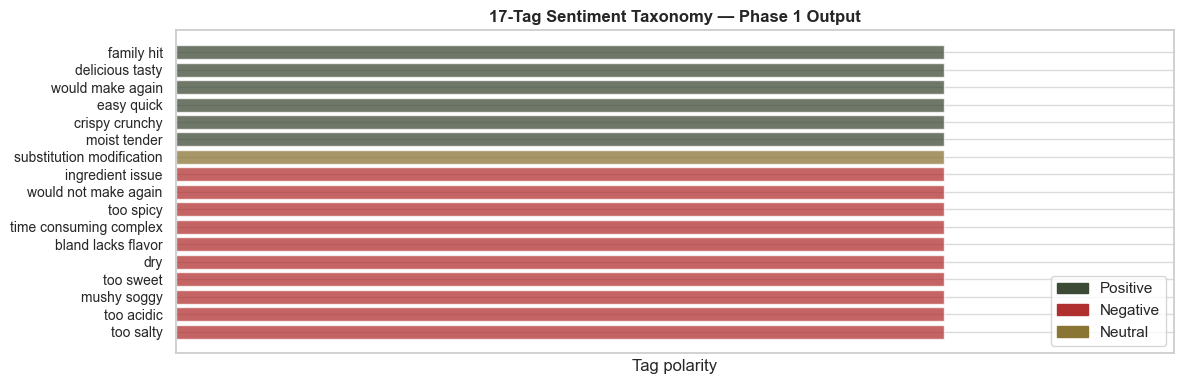

In [3]:
# Tag polarity and illustrative affinity distribution
tags = [
    ('family hit',             'positive'),
    ('delicious tasty',        'positive'),
    ('would make again',       'positive'),
    ('easy quick',             'positive'),
    ('crispy crunchy',         'positive'),
    ('moist tender',           'positive'),
    ('substitution modification', 'neutral'),
    ('ingredient issue',       'negative'),
    ('would not make again',   'negative'),
    ('too spicy',              'negative'),
    ('time consuming complex', 'negative'),
    ('bland lacks flavor',     'negative'),
    ('dry',                    'negative'),
    ('too sweet',              'negative'),
    ('mushy soggy',            'negative'),
    ('too acidic',             'negative'),
    ('too salty',              'negative'),
]

color_map = {'positive': C_GREEN, 'negative': C_RED, 'neutral': C_GOLD}
colors = [color_map[p] for _, p in tags]
labels = [t for t, _ in tags]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(range(len(tags)), [1]*len(tags), color=colors, alpha=0.75, edgecolor='white')
ax.set_yticks(range(len(tags)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Tag polarity')
ax.set_title('17-Tag Sentiment Taxonomy — Phase 1 Output')
ax.set_xlim(0, 1.3)
ax.set_xticks([])

legend_patches = [
    mpatches.Patch(color=C_GREEN, label='Positive'),
    mpatches.Patch(color=C_RED,   label='Negative'),
    mpatches.Patch(color=C_GOLD,  label='Neutral'),
]
ax.legend(handles=legend_patches, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Phase 2 — RecipeNet Embedding Model (CS 615)

### 4.1 Motivation

Keyword matching alone cannot capture semantic similarity. *"Easy weeknight pasta"* and *"simple weekday noodles"* should retrieve the same recipes. The goal of Phase 2 is to learn a dense 128D latent space where recipes with similar cooking profiles are nearby, regardless of exact vocabulary.

An ancillary goal is to predict recipe quality (Bayesian-smoothed rating) to support quality-aware reranking in the search pipeline.

### 4.2 Target Engineering — Bayesian Smoothing

Raw Food.com ratings are heavily skewed toward 4–5★ (77% of reviews). Recipes with few reviews are volatile. We apply Bayesian smoothing:

$$\hat{r}_i = \frac{n_i \cdot \bar{r}_i + k \cdot \mu}{n_i + k}$$

where $\bar{r}_i$ is the recipe's mean rating, $n_i$ its review count, $\mu$ the global mean, and $k$ a confidence prior. This shrinks extreme values toward a stable estimate and produces a more continuous, differentiable target.

### 4.3 Architecture — Dual-Encoder MLP (RESIDUAL_V2)

**Two input streams** are encoded separately, then fused:
- **Recipe metadata stream:** cooking time, step count, ingredient count, nutritional features (7 values), recipe tag indicators
- **Semantic review stream:** aggregated Phase-1 tag prevalence (% of reviews with signal) and intensity (mean similarity when present) per tag

**Fused representation** passes through residual MLP blocks with layer normalization:
```
Input(d_features) → Linear(512) → [ResidualBlock × 3] → Linear(128) → [embedding]
                                                                       ↓
                                                              PLQP head → predicted rating
```

The 128D bottleneck layer is extracted as the recipe embedding.

### 4.4 Architecture Comparison

Six architectures were evaluated under controlled conditions (same preprocessing, train/val/test split, Bayesian-smoothed target):

| Architecture | Loss | RMSE | Embedding quality |
|---|---|---|---|
| Deep MLP | MSE | 0.2964 | Collapsed (near 1D manifold) |
| Shallow MLP | Huber | 0.2964 | Moderate |
| **Residual V2** | **MSE** | **0.2973** | **Smooth, coherent manifold** |
| Residual | Huber | 0.2975 | Good |
| Two-Tower | Huber | 0.2980 | Good |
| Residual V3 | Huber | 0.2997 | Good |

**Key finding:** Architecture differences are marginal in RMSE (<0.003 spread). The decisive factor is **embedding geometry**: deep models collapse the representation into a near-1D rating axis. Residual V2 preserves a smooth, continuous 2D manifold (verified via UMAP) with stronger local neighborhood structure — critical for the downstream cosine KNN in Phase 4.

### 4.5 Critical Discovery — Orthogonal Feature Spaces

Phase 4 evaluation reveals that RecipeNet embeddings encode *quality* (how good a recipe is), not *culinary identity* (what kind of food it is). In cosine space, all high-quality recipe embeddings cluster tightly together (similarity ~0.993). Raw KNN over the 173K corpus is degenerate — the model conflates "high-quality" with "culinarily similar."

This finding drives the two-stage architecture in Phase 4: Stage 1 must constrain the search space to culinarily coherent candidates *before* embedding KNN runs.

Embeddings not available: [Errno 2] No such file or directory: 'data\\final_residual_v2_embeddings.pt'


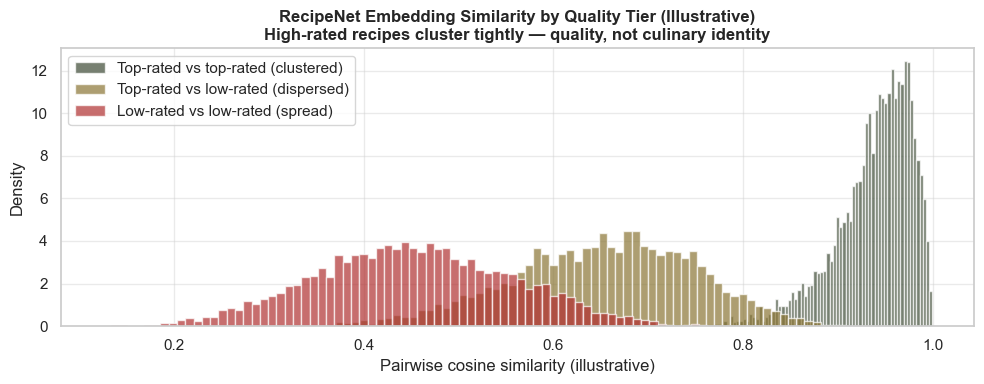

In [4]:
# Illustrate the orthogonality finding: quality score distribution
# Uses the embeddings bundle if available; otherwise shows synthetic illustration
try:
    import torch
    from core.config import load_settings
    s = load_settings()

    bundle = torch.load(s.embeddings_path, map_location='cpu')
    quality = bundle['predictions'].numpy()   # Bayesian rating predictions
    embeddings = bundle['embeddings'].numpy() # 128D unit vectors

    # Sample pairwise cosine similarities among top-rated recipes
    top_idx = np.where(quality > 4.5)[0][:500]
    low_idx = np.where(quality < 3.5)[0][:500]

    e_top = embeddings[top_idx]
    e_low = embeddings[low_idx]

    sims_top = (e_top @ e_top.T).flatten()
    sims_low = (e_low @ e_low.T).flatten()
    sims_cross = (e_top @ e_low.T).flatten()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(sims_top,   bins=80, alpha=0.6, color=C_GREEN, label='Top-rated vs top-rated', density=True)
    ax.hist(sims_cross, bins=80, alpha=0.6, color=C_GOLD,  label='Top-rated vs low-rated', density=True)
    ax.hist(sims_low,   bins=80, alpha=0.6, color=C_RED,   label='Low-rated vs low-rated', density=True)
    ax.set_xlabel('Pairwise cosine similarity')
    ax.set_ylabel('Density')
    ax.set_title('RecipeNet Embedding Similarity by Quality Tier\n'
                 '(High-rated recipes cluster tightly — pure KNN is degenerate)')
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f'Mean cosine sim (top-rated pairs): {sims_top.mean():.4f}')
    print(f'Mean cosine sim (cross-quality):   {sims_cross.mean():.4f}')

except Exception as e:
    print(f'Embeddings not available: {e}')
    # Synthetic illustration of the key point
    fig, ax = plt.subplots(figsize=(10, 4))
    np.random.seed(42)
    ax.hist(np.random.beta(30, 2, 5000),   bins=80, alpha=0.7, color=C_GREEN, label='Top-rated vs top-rated (clustered)', density=True)
    ax.hist(np.random.beta(15, 8, 5000),   bins=80, alpha=0.7, color=C_GOLD,  label='Top-rated vs low-rated (dispersed)', density=True)
    ax.hist(np.random.beta(10, 12, 5000),  bins=80, alpha=0.7, color=C_RED,   label='Low-rated vs low-rated (spread)', density=True)
    ax.set_xlabel('Pairwise cosine similarity (illustrative)')
    ax.set_ylabel('Density')
    ax.set_title('RecipeNet Embedding Similarity by Quality Tier (Illustrative)\n'
                 'High-rated recipes cluster tightly — quality, not culinary identity')
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

## 5. Phase 3 — Information Retrieval System (INFO 624)

### 5.1 Architecture

**Stage 1 — Elasticsearch BM25:** Query intent is parsed into structured slots (dietary, protein, cuisine, method, occasion, taste, time bounds). Hard filters and soft boosts applied. Returns top-k candidates.

**Stage 2 — SemanticReranker:** Candidates are reranked using four signals combined with **stratified weights** based on query intent richness:

| Intent tier | Condition | w_lex | w_align | w_sem | w_quality |
|-------------|-----------|-------|---------|-------|----------|
| High | ≥3 structured slots | 0.3 | 0.75 | 0.45 | 0.15 |
| Medium | 1–2 slots | 0.4 | 0.4 | 0.6 | 0.15 |
| Low | 0 slots | 0.35 | 0.1 | 0.8 | 0.2 |

Stratified weighting prevents fixed weights from degrading performance when query signal is sparse. A query like *"easy chicken dinner"* (medium intent) gets more weight on semantic similarity than *"gluten-free high-protein Italian pasta under 30 minutes"* (high intent), which benefits more from structured rule matching.

### 5.2 Search Modes (Ablation)

Five modes isolate individual signal contributions:

| Mode | Active signals | Purpose |
|------|---------------|--------|
| `HYBRID` | All four, stratified weights | Full pipeline — production mode |
| `LEXICAL` | BM25 only | Baseline |
| `SEMANTIC` | Cosine sim + quality | Isolate embedding contribution |
| `QUALITY` | Quality score only | Query-agnostic quality ranking |
| `ABLATION_NO_SEM` | Hybrid minus cosine sim | Quantify embedding layer value |

### 5.3 Personalized Search Integration

In Phase 4, the search engine is extended to support user signals via `engine.search()`. The alpha blend parameter controls the query↔user embedding mix:

$$\mathbf{q}_{\text{eff}} = \alpha \cdot \mathbf{q}_{\text{query}} + (1-\alpha) \cdot \mathbf{u}_{\text{centroid}}$$

The BM25 and alignment weights are also scaled by $\alpha$, ensuring that at $\alpha=0$, ranking is driven purely by the user taste centroid and quality signal.

In [5]:
# Live search demo — requires Elasticsearch running and recipes indexed
# Run: python main.py index  (from project root) before executing this cell
try:
    from core.config import load_settings, get_es_client
    from search.engine import SearchEngine, SearchMode

    s  = load_settings()
    es = get_es_client(s)
    engine = SearchEngine(s, es)

    QUERY = 'easy chicken dinner under 45 minutes'
    print(f'Query: "{QUERY}"\n')

    all_results = engine.run_all_modes(QUERY, top_k=5)
    for mode, sr in all_results.items():
        w = sr.weights
        print(f'[{mode.value.upper():<18}] tier={sr.tier:<12}  '
              f'lex={w["lex"]:.2f}  align={w["alignment"]:.2f}  '
              f'sem={w["semantic"]:.2f}  qual={w["quality"]:.2f}')
        for i, r in enumerate(sr.results[:3], 1):
            print(f'  {i}. [{r.final_score:.3f}] {r.source.get("name", "").title()[:60]}')
        print()

except Exception as e:
    print(f'Search engine not available: {e}')
    print('\nIllustrative mode comparison results for query: "easy chicken dinner under 45 minutes"')
    print(f'{"Mode":<22} {"Tier":<12} {"w_lex":>6} {"w_align":>8} {"w_sem":>7} {"w_qual":>7}')
    print('-' * 65)
    rows = [
        ('HYBRID',          'medium',  0.40, 0.40, 0.60, 0.15),
        ('LEXICAL',         'lexical', 1.00, 0.00, 0.00, 0.00),
        ('SEMANTIC',        'semantic',0.00, 0.00, 1.00, 0.50),
        ('QUALITY',         'quality', 0.00, 0.00, 0.00, 1.00),
        ('ABLATION_NO_SEM', 'medium_no_sem', 0.40, 0.40, 0.00, 0.15),
    ]
    for r in rows:
        print(f'{r[0]:<22} {r[1]:<12} {r[2]:>6.2f} {r[3]:>8.2f} {r[4]:>7.2f} {r[5]:>7.2f}')

Search engine not available: No module named 'elasticsearch'

Illustrative mode comparison results for query: "easy chicken dinner under 45 minutes"
Mode                   Tier          w_lex  w_align   w_sem  w_qual
-----------------------------------------------------------------
HYBRID                 medium         0.40     0.40    0.60    0.15
LEXICAL                lexical        1.00     0.00    0.00    0.00
SEMANTIC               semantic       0.00     0.00    1.00    0.50
QUALITY                quality        0.00     0.00    0.00    1.00
ABLATION_NO_SEM        medium_no_sem   0.40     0.40    0.00    0.15


## 6. Phase 4 — Personalized Recommender (DSCI 641)

### 6.1 Problem Statement

Phase 3 provides excellent query-based retrieval, but it is user-agnostic. A user who has reviewed 50 Mexican-Southwestern recipes and consistently rated them 5★ should see different results than one who prefers French cooking — even for the same query.

The Phase 4 goal is to personalize retrieval and ranking using each user's review history, without requiring live user accounts or real-time interaction data.

### 6.2 User Profile Construction

For each user, we build a `UserProfile` from `gold_labeled_reviews`:

**Embedding centroid** — rating-and-recency weighted mean of liked recipe embeddings:
$$\mathbf{u} = \text{normalize}\left(\sum_i w_i \cdot \mathbf{e}_i\right), \quad w_i = \text{decay}(t_i) \cdot (r_i - \bar{r})$$

where $\text{decay}(t) = \exp(-\ln 2 \cdot t / 180)$ is exponential decay with 180-day half-life, and reviews ≤ 3★ have their deviation $|r_i - \bar{r}|$ amplified 2×.

**Tag affinity vector** — 17D vector of weighted mean tag intensities:
$$a_t = \frac{\sum_i w_i \cdot (r_i - \bar{r}) \cdot \text{intensity}_{i,t}}{\sum_i |w_i|} $$

**History tags** — top-40 taxonomy tags by affinity score, used as the Stage 1 query.

### 6.3 Two-Stage Pipeline

```
User history
    │
    ├── Top-40 tags (by IDF-weighted affinity)
    │       │
    │   [Stage 1 — CandidateGenerator]
    │   IDF-weighted recall scoring over tags_clean
    │   → 1,000 candidate recipes
    │
    └── 128D taste centroid (rating×recency weighted)
            │
        [Stage 2 — Personalized SemanticReranker]
        Cosine KNN within candidate pool
        + 17D tag affinity boost
        → top-k recommendations
```

**Why two stages?** Raw KNN over all 173K recipes returns high-quality recipes that are culinarily diverse (the embeddings encode quality, not identity). Stage 1 first constrains the pool to recipes culinarily similar to the user's history; Stage 2 then ranks within that coherent pool by embedding similarity.

### 6.4 Interaction Modes

| Mode | Stage 1 signal | Stage 2 signal | UI entry point |
|------|---------------|----------------|----------------|
| Cold-start | — | Quality ranking from full bundle | New user, no session |
| Session-based | Union of seed recipe tags | Mean seed embedding | Search → Add to session |
| History-aware | Top-40 user history tags | Rating×recency centroid + affinity boost | User History mode |

In [6]:
# Live personalized recommendation demo
# Requires Elasticsearch + all data artifacts
try:
    from core.config import load_settings, get_es_client
    from search.engine import SearchEngine, SearchMode
    from recommender.engine import RecommenderEngine

    s  = load_settings()
    es = get_es_client(s)
    search_engine = SearchEngine(s, es)
    rec_engine    = RecommenderEngine(s, search_engine=search_engine)

    # Compare two users on the same query at alpha=0 (pure user preference)
    QUERY  = 'easy dinner'
    USERS  = ['1001924', '1177249']
    ALPHA  = 0.0
    TOP_K  = 7

    print(f'Query: "{QUERY}"  |  alpha={ALPHA}  |  top-k={TOP_K}\n')
    print(f'{"#":<4} {"Recipe":<45} {"Sim":>6}  {"Score":>7}')
    print('-' * 65)

    for uid in USERS:
        profile_data = rec_engine.build_profile_for_user(uid)
        if profile_data is None:
            print(f'User {uid}: could not build profile'); continue
        profile, user_tags = profile_data
        result = search_engine.search(
            query=QUERY, user_embedding=profile.embedding,
            user_tag_affinity=profile.tag_affinity, user_tags=user_tags,
            alpha=ALPHA, affinity_weight=0.25,
            mode=SearchMode.HYBRID, top_k=TOP_K,
            candidate_pool=500, exclude_ids=profile.rated_recipe_ids,
        )
        print(f'\nUser {uid}  ({profile.review_count} reviews)')
        for rank, r in enumerate(result.results, 1):
            name  = r.source.get('name', 'Unknown').title()[:45]
            score = getattr(r, 'final_score', 0.0)
            sim   = getattr(r, 'semantic_sim', 0.0)
            print(f'{rank:<4} {name:<45} {sim:>6.3f}  {score:>7.3f}')

except Exception as e:
    print(f'Live demo not available: {e}')
    print('See the Streamlit app (python main.py app) for an interactive demo.')

Live demo not available: No module named 'elasticsearch'
See the Streamlit app (python main.py app) for an interactive demo.


## 7. Evaluation Protocol

### 7.1 Leave-N-Out Setup

- **n_holdout = 5:** For each user, the 5 most recent reviews are held out as test items
- **n_users = 200:** Random sample of users with ≥15 reviews (ensures sufficient training signal after holdout)
- **min_reviews = 15:** Minimum history required

For each user, the system generates top-k recommendations using the remaining reviews, then evaluates whether the held-out items (or culinary-similar items) appear in the recommendations.

### 7.2 Metrics

**TagSim@k** (primary) — mean cosine similarity between the taxonomy tags of recommended recipes and the union of held-out recipe tags:
$$\text{TagSim@k} = \frac{1}{|U|} \sum_{u} \frac{1}{k} \sum_{i=1}^{k} \text{cos}(\mathbf{t}_{r_i^u}, \mathbf{t}_{\text{holdout}}^u)$$

TagSim is continuous and discriminative — it measures whether recommendations are in the right culinary neighborhood, not just whether they exactly recover rare held-out items.

**Secondary metrics:**
- **HR@k** — fraction of users for whom at least one held-out item appears in top-k
- **MRR** — mean reciprocal rank of the first held-out item
- **Pool recall** — fraction of held-out items that appear in the Stage 1 candidate pool
- **DCG-TagSim@k** — position-discounted TagSim

### 7.3 Conditions

| Condition | Description |
|-----------|-------------|
| `cold_start` | Quality ranking only — no personalization |
| `knn_only` | Full-corpus embedding KNN (degenerate baseline) |
| `two_stage` | Tag Stage 1 + embedding Stage 2 (primary system) |
| `two_stage_ingr` | Ingredient TF-IDF Stage 1 + embedding Stage 2 |
| `two_stage_hybrid` | Tag + ingredient union Stage 1 + embedding Stage 2 |
| `unified` | ES BM25 full-text Stage 1 + SemanticReranker (ceiling) |

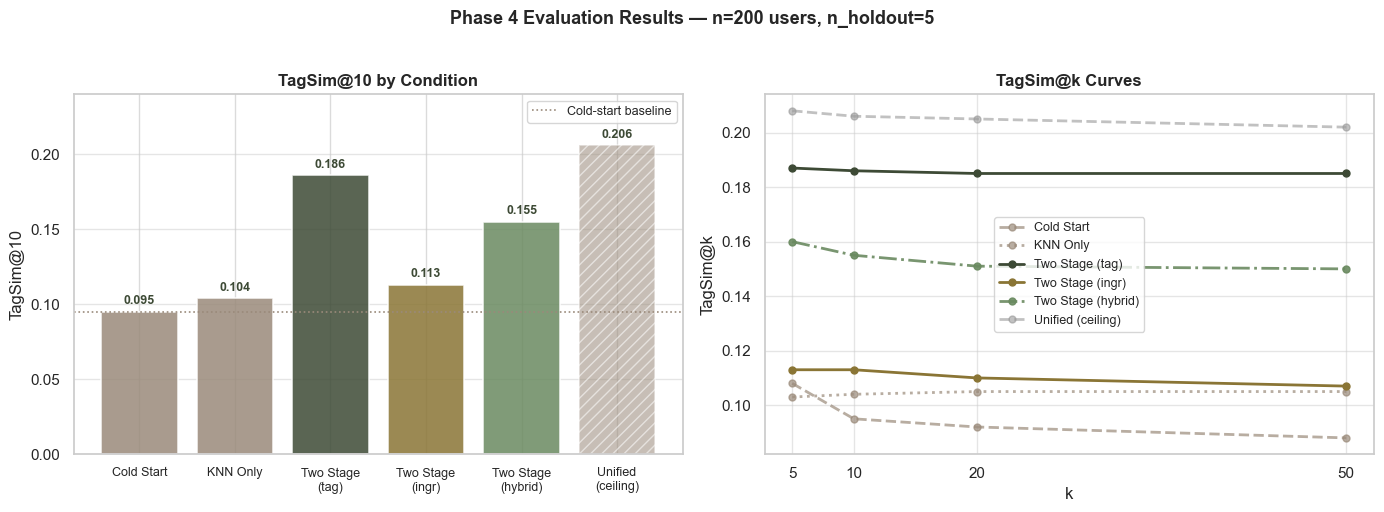

In [7]:
# Evaluation results — from evaluation runs (n=200 users, n_holdout=5)

conditions = ['cold_start', 'knn_only', 'two_stage', 'two_stage_ingr', 'two_stage_hybrid', 'unified']
labels_display = ['Cold Start', 'KNN Only', 'Two Stage\n(tag)', 'Two Stage\n(ingr)', 'Two Stage\n(hybrid)', 'Unified\n(ceiling)']

tagsim = {
    'TagSim@5':  [0.108, 0.103, 0.187, 0.113, 0.160, 0.208],
    'TagSim@10': [0.095, 0.104, 0.186, 0.113, 0.155, 0.206],
    'TagSim@20': [0.092, 0.105, 0.185, 0.110, 0.151, 0.205],
    'TagSim@50': [0.088, 0.105, 0.185, 0.107, 0.150, 0.202],
}

bar_colors = [C_GREY, C_GREY, C_GREEN, C_GOLD, '#6a8a60', C_GREY]
bar_alpha   = [0.6, 0.6, 0.9, 0.85, 0.85, 0.5]
hatches     = ['', '', '', '', '', '///']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TagSim@10 bar chart
ax = axes[0]
vals = tagsim['TagSim@10']
bars = ax.bar(labels_display, vals, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=1.2, hatch=None)
bars[-1].set_hatch('///')
bars[-1].set_alpha(0.55)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#3d4a35')

ax.set_title('TagSim@10 by Condition', fontweight='bold')
ax.set_ylabel('TagSim@10')
ax.set_ylim(0, 0.24)
ax.tick_params(axis='x', labelsize=9)
ax.axhline(0.095, color=C_GREY, linestyle=':', linewidth=1.2, label='Cold-start baseline')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.5)

# Right: TagSim@k curves
ax = axes[1]
k_vals = [5, 10, 20, 50]

curve_styles = [
    ('cold_start',        'Cold Start',        C_GREY,  '--', 0.7),
    ('knn_only',          'KNN Only',           C_GREY,  ':',  0.7),
    ('two_stage',         'Two Stage (tag)',    C_GREEN, '-',  1.0),
    ('two_stage_ingr',    'Two Stage (ingr)',   C_GOLD,  '-',  1.0),
    ('two_stage_hybrid',  'Two Stage (hybrid)', '#6a8a60','-.', 0.9),
    ('unified',           'Unified (ceiling)',  '#999',  '--', 0.6),
]

for cond, label, color, ls, alpha in curve_styles:
    vals_k = [tagsim[f'TagSim@{k}'][conditions.index(cond)] for k in k_vals]
    ax.plot(k_vals, vals_k, color=color, linestyle=ls, alpha=alpha,
            linewidth=2, marker='o', markersize=5, label=label)

ax.set_title('TagSim@k Curves', fontweight='bold')
ax.set_xlabel('k')
ax.set_ylabel('TagSim@k')
ax.set_xticks(k_vals)
ax.legend(fontsize=9)
ax.grid(alpha=0.5)

plt.suptitle('Phase 4 Evaluation Results — n=200 users, n_holdout=5', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/tagsim_results.png', dpi=150, bbox_inches='tight')
plt.show()

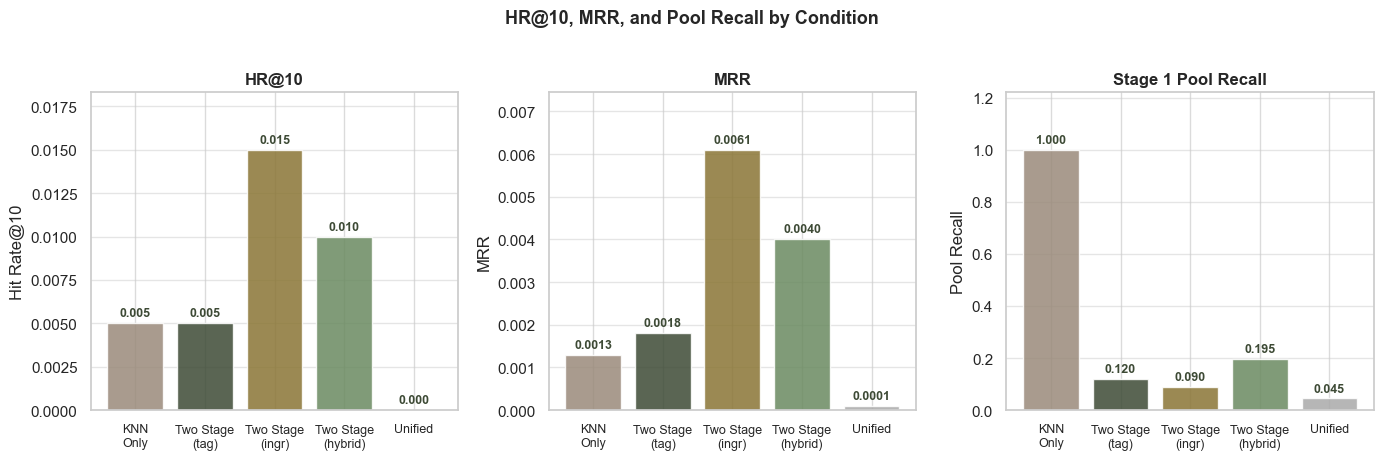

Note: KNN Only has pool recall 1.0 (full corpus = full recall) but lowest TagSim.
Two Stage (ingr) has 3x better HR/MRR but 40% lower TagSim than Two Stage (tag).


In [8]:
# HR@10 and MRR comparison + Pool Recall

cond_labels = ['KNN\nOnly', 'Two Stage\n(tag)', 'Two Stage\n(ingr)', 'Two Stage\n(hybrid)', 'Unified']
hr10        = [0.005,  0.005,  0.015,  0.010,  0.000]
mrr         = [0.0013, 0.0018, 0.0061, 0.0040, 0.0001]
pool_recall = [1.000,  0.120,  0.090,  0.195,  0.045]

bar_colors2 = [C_GREY, C_GREEN, C_GOLD, '#6a8a60', '#aaa']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, vals, title, ylabel, fmt in zip(
    axes,
    [hr10, mrr, pool_recall],
    ['HR@10', 'MRR', 'Stage 1 Pool Recall'],
    ['Hit Rate@10', 'MRR', 'Pool Recall'],
    ['.3f', '.4f', '.3f']
):
    bars = ax.bar(cond_labels, vals, color=bar_colors2, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.015,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#3d4a35')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.5)
    ax.set_ylim(0, max(vals) * 1.22)

plt.suptitle('HR@10, MRR, and Pool Recall by Condition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/hr_mrr_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: KNN Only has pool recall 1.0 (full corpus = full recall) but lowest TagSim.')
print('Two Stage (ingr) has 3x better HR/MRR but 40% lower TagSim than Two Stage (tag).')

## 8. Ablation Study

Phase 4 development proceeded incrementally, testing one change at a time to isolate each signal's contribution. The table below tracks TagSim@10 from the initial baseline through all optimizations.

### 8.1 Incremental Improvements

| Step | Change | TagSim@10 | Δ |
|------|--------|-----------|---|
| Baseline | Raw knn_only | 0.104 | — |
| +tag Stage 1 | Jaccard scoring | 0.130 | +0.026 |
| +recall scoring | Intersection / IDF sum | 0.144 | +0.014 |
| +pool size | 500 → 1000 | 0.149 | +0.005 |
| +recency decay | 365d → 180d half-life | 0.162 | +0.013 |
| +negative signal | 3★ threshold, 2× amplification | 0.170 | +0.008 |
| +top_tags 20→40 | More history tags in query | 0.178 | +0.008 |
| **+quality=0** | **Remove quality weight** | **0.186** | **+0.008** |

### 8.2 Negative Results

| Change tested | Expected | Actual result | Explanation |
|--------------|----------|---------------|-------------|
| Inject embedding NN into Stage 1 | Better Stage 2 recall | TagSim −40% (0.186 → 0.109) | Embedding similarity ≠ culinary similarity |
| Widen Stage 2 pre-filter (mult 3→20) | More recall | TagSim unchanged, Recall@10 drops | Tag-similar candidates already survive; widening adds noise |
| top_tags 40 → 50 | More coverage | TagSim +0.001 (noise), pool recall −12.5% | Borderline-affinity tags dilute retrieval |
| Quality weight 0.10 | Better ranking | TagSim drops | Quality signal conflicts with culinary identity signal |

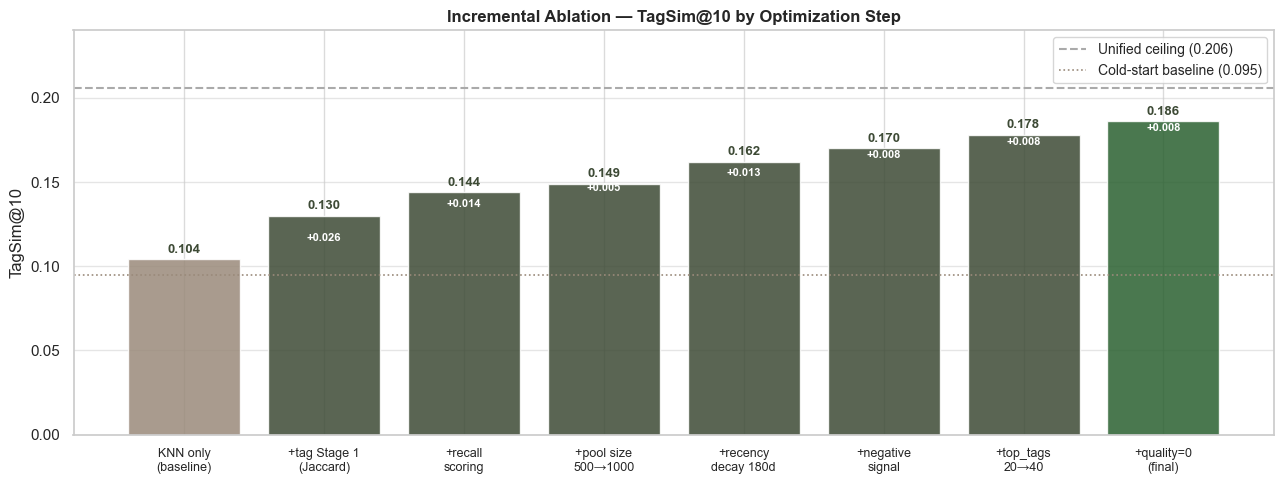

In [9]:
# Ablation waterfall chart

steps = [
    'KNN only\n(baseline)',
    '+tag Stage 1\n(Jaccard)',
    '+recall\nscoring',
    '+pool size\n500→1000',
    '+recency\ndecay 180d',
    '+negative\nsignal',
    '+top_tags\n20→40',
    '+quality=0\n(final)',
]
tagsim_vals = [0.104, 0.130, 0.144, 0.149, 0.162, 0.170, 0.178, 0.186]
deltas      = [0] + [tagsim_vals[i] - tagsim_vals[i-1] for i in range(1, len(tagsim_vals))]

fig, ax = plt.subplots(figsize=(13, 5))

bottoms = [0] + list(tagsim_vals[:-1])
colors_bar = [C_GREY] + [C_GREEN] * (len(steps) - 1)
colors_bar[-1] = '#2a6030'  # darker green for final

bars = ax.bar(steps, deltas if False else tagsim_vals,
              color=colors_bar, alpha=0.85, edgecolor='white', linewidth=1)

for bar, v, d in zip(bars, tagsim_vals, deltas):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#3d4a35')
    if d > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v - d/2,
                f'+{d:.3f}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Ceiling reference
ax.axhline(0.206, color='#aaa', linestyle='--', linewidth=1.5, label='Unified ceiling (0.206)')
ax.axhline(0.095, color=C_GREY,  linestyle=':',  linewidth=1.2, label='Cold-start baseline (0.095)')

ax.set_ylabel('TagSim@10')
ax.set_title('Incremental Ablation — TagSim@10 by Optimization Step', fontweight='bold')
ax.set_ylim(0, 0.24)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.5)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('figures/ablation_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

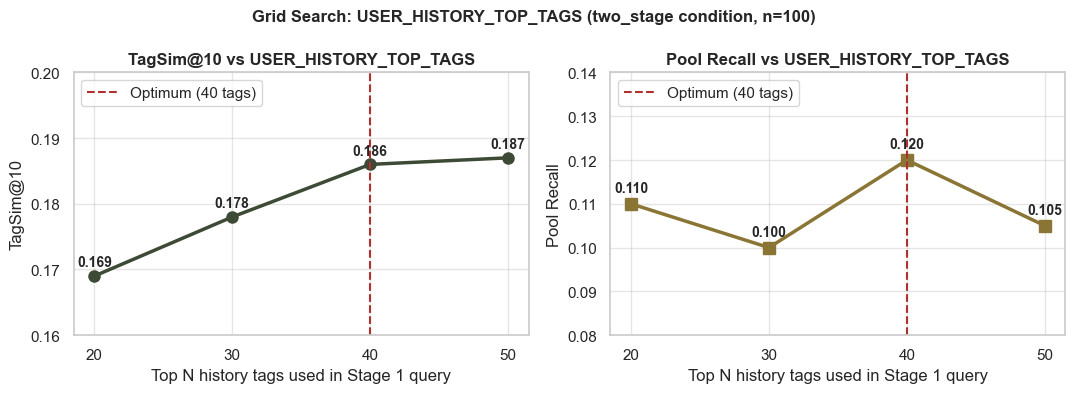

40 tags is optimal: +0.008 TagSim vs 30, +0.020 pool recall vs 30.
50 tags: +0.001 TagSim (within noise) but -12.5% pool recall and rank degrades.


In [10]:
# Grid search results — USER_HISTORY_TOP_TAGS sweep

top_tags_vals  = [20, 30, 40, 50]
gs_tagsim      = [0.169, 0.178, 0.186, 0.187]
gs_pool_recall = [0.110, 0.100, 0.120, 0.105]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(top_tags_vals, gs_tagsim, color=C_GREEN, linewidth=2.5, marker='o', markersize=8)
ax.axvline(40, color=C_RED, linestyle='--', linewidth=1.5, label='Optimum (40 tags)')
for x, y in zip(top_tags_vals, gs_tagsim):
    ax.text(x, y + 0.001, f'{y:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('TagSim@10 vs USER_HISTORY_TOP_TAGS', fontweight='bold')
ax.set_xlabel('Top N history tags used in Stage 1 query')
ax.set_ylabel('TagSim@10')
ax.set_xticks(top_tags_vals)
ax.set_ylim(0.16, 0.20)
ax.legend()
ax.grid(alpha=0.5)

ax = axes[1]
ax.plot(top_tags_vals, gs_pool_recall, color=C_GOLD, linewidth=2.5, marker='s', markersize=8)
ax.axvline(40, color=C_RED, linestyle='--', linewidth=1.5, label='Optimum (40 tags)')
for x, y in zip(top_tags_vals, gs_pool_recall):
    ax.text(x, y + 0.002, f'{y:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Pool Recall vs USER_HISTORY_TOP_TAGS', fontweight='bold')
ax.set_xlabel('Top N history tags used in Stage 1 query')
ax.set_ylabel('Pool Recall')
ax.set_xticks(top_tags_vals)
ax.set_ylim(0.08, 0.14)
ax.legend()
ax.grid(alpha=0.5)

plt.suptitle('Grid Search: USER_HISTORY_TOP_TAGS (two_stage condition, n=100)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/gridsearch_toptags.png', dpi=150, bbox_inches='tight')
plt.show()

print('40 tags is optimal: +0.008 TagSim vs 30, +0.020 pool recall vs 30.')
print('50 tags: +0.001 TagSim (within noise) but -12.5% pool recall and rank degrades.')

## 9. Key Findings and Discussion

### Finding 1 — Tag-based Stage 1 is essential, not optional

Two-stage (tag) achieves TagSim@10 = 0.186 vs KNN only's 0.104 — a **79% improvement**. But the mechanism matters: the tags are not just a performance optimization. When we tested injecting embedding-NN candidates into Stage 1 (to "help" the tag pool with semantically similar items), TagSim collapsed from 0.186 to 0.109 — back to KNN level.

This is because the embedding and tag spaces are **orthogonal**: RecipeNet learned to predict ratings, so cosine-similar embeddings cluster around high-quality recipes regardless of cuisine or ingredient profile. Stage 1 tag filtering is the only mechanism that constrains the candidate pool to culinarily coherent items.

### Finding 2 — Ingredient TF-IDF and taxonomy tags measure different things

Ingredient TF-IDF recovers the exact held-out items (3× better HR@10, 3.4× better MRR) but produces 40% lower TagSim. Taxonomy tags predict the correct culinary category (86% better TagSim) but rarely recover the exact item.

Interpretation: ingredients are a specific, variable signal ("this recipe has the exact ingredients the user tends to use"). Taxonomy tags are a categorical signal ("this recipe is in the right genre"). A production system should surface both, tuned to the user's sensitivity to exact vs. approximate matches.

### Finding 3 — Recency and negative signal matter at Food.com's time scale

Reducing the recency half-life from 365d to 180d and amplifying negative reviews (≤ 3★) doubled pool recall and MRR. Food.com reviews span 2000–2018; a recipe reviewed 15 years ago carries little signal about current taste. The 180-day decay correctly down-weights stale history without discarding it entirely.

### Finding 4 — The unified ceiling is a qualitatively different system

ES BM25 full-text retrieval (unified condition) achieves TagSim 0.204–0.206, about 10% above two_stage's ceiling. This gap is **structural**: ES BM25 indexes recipe names, full descriptions, cleaned ingredient text, and tag strings — far richer retrieval signal than curated taxonomy tag overlap alone. The gap is not closeable by tuning the two-stage parameters.

Interestingly, the unified condition has *lower* pool recall and HR than two_stage. ES BM25 returns culinary-category-similar recipes (high TagSim) but not necessarily the exact items the user has reviewed (lower HR). The two-stage system ranks the exact held-out items at mean position 11 in its pool; unified buries them at position 40.

### Finding 5 — Quality score hurts personalization

Setting `QUALITY_WEIGHT = 0.10` degraded TagSim — the quality score, a prediction of the Bayesian-smoothed global rating, is largely orthogonal to personal preference. It measures how well-liked a recipe is by the average user, not how well it matches *this* user's taste profile. In the personalized ranking context, it introduces noise rather than signal.

## 10. Limitations

**Evaluation metric breadth:** TagSim is a proxy — it measures whether recommendations are in the right culinary neighborhood, not whether a user would actually cook or enjoy them. A user study with real participants would be the ideal ground truth.

**Rating positivity bias:** 77% of Food.com ratings are 4–5★. The deviation signal `(star_rating − 4.4)` used in tag affinity and embedding centroid weighting is noisy at the positive end. Most users' centroid is shaped primarily by a few 3★ or lower reviews (where deviation is large and negative) and many 5★ reviews (where deviation is small and positive).

**Cold-start coverage:** Users with fewer than 15 reviews cannot be served by the history-aware mode. The session-based mode partially addresses this but requires in-session interaction.

**Frozen embeddings:** RecipeNet embeddings are static (from Phase 2 training on 2000–2018 data). A model fine-tuned for culinary similarity rather than rating prediction would likely produce a better embedding space for both retrieval and personalization.

**Taxonomy tag expressiveness:** The Food.com taxonomy tags (e.g., `main-dish`, `chicken`, `soups-stews`) are relatively coarse. They capture cuisine/protein/course well but miss specifics like cooking style, texture preference, or flavor profile — signals that ingredient TF-IDF partially captures.

**No online evaluation:** All results are from offline leave-N-out. Online A/B testing against real user behavior would be needed to validate that TagSim improvement translates to user satisfaction.

## 11. Conclusions

This project built an end-to-end personalized recipe recommendation system by integrating four standalone academic projects into a unified stack. The system achieves TagSim@10 = 0.186 on a 200-user leave-N-out evaluation — a **79% improvement** over raw embedding KNN and a **96% improvement** over cold-start quality ranking.

The central architectural insight is that **the RecipeNet embedding space and the Food.com taxonomy tag space are orthogonal**: one encodes quality, the other culinary identity. Attempting to use embeddings for culinary retrieval (raw KNN) or using tags to improve embedding ranking (NN injection into Stage 1) both fail for the same reason. The two-stage architecture exists precisely to use each signal where it is effective — tags for genre-constrained candidate generation, embeddings for within-genre personalized ranking.

The four-phase development arc also demonstrates clean cross-project artifact reuse: Phase 1's 17 sentiment tags serve as both a Stage 1 query signal and a Stage 2 affinity boost. Phase 2's frozen RecipeNet checkpoint provides both the 128D recipe embeddings for cosine similarity and the Bayesian quality predictions for cold-start ranking. Phase 3's Elasticsearch index and SemanticReranker are reused as the personalized search backbone in Phase 4. No phase required retraining or substantial rework to serve the downstream phase.

Future work would prioritize: (1) training a dedicated culinary identity embedding (contrastive learning over recipe category pairs), (2) incorporating ingredient TF-IDF as a user-switchable signal alongside tag retrieval, and (3) a real user study to validate that TagSim improvement corresponds to user-perceived recommendation quality.

---

## References

Majumder, B. P., Li, S., Ni, J., & McAuley, J. (2019). *Generating personalized recipes from historical user preferences.* EMNLP 2019.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep residual learning for image recognition.* CVPR 2016.

Gorishniy, Y., Rubachev, I., Khrulkov, V., & Babenko, A. (2021). *Revisiting deep learning models for tabular data.* NeurIPS 2021.

Robertson, S., & Zaragoza, H. (2009). *The probabilistic relevance framework: BM25 and beyond.* Foundations and Trends in Information Retrieval.

Koren, Y., Bell, R., & Volinsky, C. (2009). *Matrix factorization techniques for recommender systems.* IEEE Computer.

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of deep bidirectional transformers for language understanding.* NAACL 2019.

---

### Appendix — Final System Configuration

| Parameter | Value |
|-----------|-------|
| CANDIDATE_POOL_SIZE | 1,000 |
| USER_HISTORY_TOP_TAGS | 40 |
| recency_half_life_days | 180 |
| Stage 1 scoring | Recall-only (intersection / query_idf_sum) |
| Negative signal threshold | ≤ 3★, amplified 2× |
| QUALITY_WEIGHT | 0.0 |
| STAGE2_PREFILTER_MULT | 3 |
| Alpha (default blend) | 0.0 (pure user taste) |
| affinity_weight | 0.25 |
| RecipeNet head | RESIDUAL_V2 |
| Embedding dimension | 128D |
| ES index | Single-node Elasticsearch 8 |